Código adaptado de:

[1] Documentação do PyTorch: [Learn the Basics](https://docs.pytorch.org/tutorials/beginner/basics/intro.html)

# Laboratório 0: Tutorial Pytorch

# Importações

In [1]:
!pip install torchinfo
!pip install torchinfo
!pip install torch
!pip install torchvision
!pip install matplotlib

In [2]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader     # Importa o DataLoader, que facilita o carregamento de dados em mini-lotes durante o treinamento
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision.transforms import ToTensor # Importa a transformação ToTensor, que converte imagens PIL ou NumPy arrays em tensores PyTorch
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import matplotlib.pyplot as plt             # Importa o módulo pyplot do Matplotlib, usado para criar gráficos e exibir imagens no notebook

In [3]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

# Baixar e carregar os dados

In [4]:
# Baixa os dados de treinamento a partir de conjuntos de dados públicos
training_data = datasets.FashionMNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=True,              # Indica que este é o conjunto de dados de treinamento
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=ToTensor(),    # Aplica a transformação ToTensor para converter as imagens em tensores
)

# Baixa os dados de teste a partir de conjuntos de dados públicos
test_data = datasets.FashionMNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=False,             # Indica que este é o conjunto de dados de teste
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=ToTensor(),    # Aplica a transformação ToTensor para converter as imagens em tensores
)


In [5]:
batch_size = 64                                                                     # Define o tamanho do lote, ou seja, quantas amostras serão processadas por vez
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)   # Cria o DataLoader para o conjunto de treinamento
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)        # Cria o DataLoader para o conjunto de teste

# Itera sobre o DataLoader de teste para visualizar as formas dos dados
for X, y in test_dataloader:
    # Exibe a forma e o tipo do tensor de imagens
    # N = tamanho do lote, C = canais (1 para imagens em tons de cinza), H = altura, W = largura
    print(f"Forma de X [N, C, H, W]: {X.shape}, Tipo de dados em X: {X.dtype}")

    # Exibe a forma e o tipo dos rótulos (labels)
    print(f"Forma de y: {y.shape}, Tipo de dados em y: {y.dtype}")

    break  # Encerra o loop após a primeira iteração, apenas para inspeção dos dados

Forma de X [N, C, H, W]: torch.Size([64, 1, 28, 28]), Tipo de dados em X: torch.float32
Forma de y: torch.Size([64]), Tipo de dados em y: torch.int64


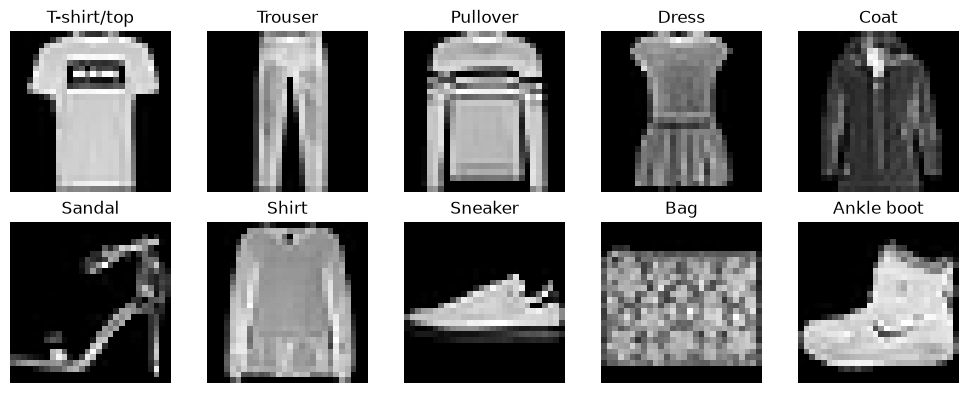

In [6]:
# Lista com os nomes das classes do conjunto de dados Fashion MNIST, na mesma ordem dos índices
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Dicionário para armazenar um exemplo por classe
examples = {}

# Itera sobre o dataset até obter um exemplo de cada classe
for img, label in training_data:
    if label not in examples:
        examples[label] = img.squeeze()  # remove o canal extra (1, 28, 28) -> (28, 28)
    if len(examples) == 10:
        break

# Plota os exemplos
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i], cmap="gray")
    plt.title(classes[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Rede Neural

## Completamente conectada

In [7]:
# Define o dispositivo de hardware para execução: usa acelerador (GPU/TPU) se disponível; caso contrário, usa a CPU
#device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = torch.device(
    'cuda' if torch.cuda.is_available() # GPU
    else 'mps' if torch.backends.mps.is_available() # MPS (Mac Silicon)
    else 'cpu' # CPU
)
print(f"Usando o dispositivo: {device}")
# Exibe qual dispositivo está sendo utilizado
print(f"Usando {device}.")

# Define a arquitetura do modelo de rede neural
class NeuralNetwork(nn.Module):
    def __init__(self):
        # Inicializa a classe base nn.Module
        super().__init__()

        # Camada que achata (flatten) as imagem 2D do conjunto de dados Fashion MNIST (28x28) para um vetor 1D (784)
        self.flatten = nn.Flatten()

        # Define uma pilha sequencial de camadas lineares (completamente conectadas) e funções de ativação ReLU
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),  # Primeira camada oculta: 784 -> 512
            nn.ReLU(),              # Função de ativação ReLU
            nn.Linear(512, 512),    # Segunda camada oculta: 512 -> 512
            nn.ReLU(),              # Função de ativação ReLU
            nn.Linear(512, 10)      # Camada de saída: 512 -> 10 (uma para cada classe)
        )

    # Define a propagação direta da entrada pelos componentes da rede neural
    def forward(self, x):
        x = self.flatten(x)                 # Achata a imagem
        logits = self.linear_relu_stack(x)  # Passa pelas camadas lineares + ReLU
        return logits                       # Retorna os valores brutos (logits), antes da softmax

# Instancia o modelo e o envia para o dispositivo escolhido (CPU ou GPU)
model = NeuralNetwork().to(device)

Usando o dispositivo: mps
Usando mps.


## Convolucional

In [8]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=128 * 3 * 3, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [9]:
# Instancia o modelo e o envia para o dispositivo escolhido (CPU ou GPU)
model_cnn = ConvNet().to(device)

## Visualização do modelo

In [10]:
# Imprime a arquitetura do modelo
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [11]:
# Visualização com torchinfo
summary(
  model, 
  input_size=(1, 1, 28, 28),
  device=device,
  col_names=( "input_size", "output_size", "num_params", "params_percent", "kernel_size", "mult_adds", "trainable")
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Param %                   Kernel Shape              Mult-Adds                 Trainable
NeuralNetwork                            [1, 1, 28, 28]            [1, 10]                   --                             --                   --                        --                        True
├─Flatten: 1-1                           [1, 1, 28, 28]            [1, 784]                  --                             --                   --                        --                        --
├─Sequential: 1-2                        [1, 784]                  [1, 10]                   --                             --                   --                        --                        True
│    └─Linear: 2-1                       [1, 784]                  [1, 512]                  401,920                    60.01%                   --                        401,920           

In [12]:
# Imprime a arquitetura do modelo
print(model_cnn)

ConvNet(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [13]:
# Visualização com torchinfo
summary(
  model_cnn, 
  input_size=(1, 1, 28, 28),  
  device=device,
  col_names=( "input_size", "output_size", "num_params", "params_percent", "kernel_size", "mult_adds", "trainable")
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Param %                   Kernel Shape              Mult-Adds                 Trainable
ConvNet                                  [1, 1, 28, 28]            [1, 10]                   --                             --                   --                        --                        True
├─Sequential: 1-1                        [1, 1, 28, 28]            [1, 128, 3, 3]            --                             --                   --                        --                        True
│    └─Conv2d: 2-1                       [1, 1, 28, 28]            [1, 32, 28, 28]           320                         0.08%                   [3, 3]                    250,880                   True
│    └─ReLU: 2-2                         [1, 32, 28, 28]           [1, 32, 28, 28]           --                             --                   --                        --              

# Treinamento

In [14]:
# Define a função de treinamento da rede neural
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)  # Obtém o número total de amostras no conjunto de dados
    model.train()  # Coloca o modelo em modo de treinamento (ativa dropout, batchnorm, etc., se houver)

    # Itera sobre os lotes de dados fornecidos pelo DataLoader
    for batch, (X, y) in enumerate(dataloader):

        X, y = X.to(device), y.to(device)   # Move os dados e rótulos para o dispositivo apropriado (CPU ou GPU)
        pred = model(X)                     # Faz a previsão do modelo para o lote atual
        loss = loss_fn(pred, y)             # Calcula o erro (função de perda) entre a previsão e os rótulos

        # Realiza a retropropagação do erro (backpropagation)
        loss.backward()         # Calcula os gradientes
        optimizer.step()        # Atualiza os pesos do modelo
        optimizer.zero_grad()   # Zera os gradientes acumulados para a próxima iteração

        # Exibe o progresso do treinamento a cada 100 batches
        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)  # Converte a perda para valor escalar e calcula amostras processadas
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")  # Exibe a perda e o progresso


In [15]:
# Define a função de teste/validação do modelo
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)  # Obtém o número total de amostras no conjunto de teste
    num_batches = len(dataloader)   # Obtém o número total de batches (lotes)
    model.eval()                    # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
    test_loss, correct = 0, 0       # Inicializa as variáveis para perda total e número de acertos

    # Desativa o cálculo de gradientes para economizar memória e acelerar a execução
    with torch.no_grad():
        # Itera sobre os batches do conjunto de teste
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)       # Move os dados e rótulos para o dispositivo adequado (CPU ou GPU)
            pred = model(X)                         # Faz a previsão com o modelo
            test_loss += loss_fn(pred, y).item()    # Acumula a perda do lote atual
            correct += (pred.argmax(dim=1) == y).type(torch.float).sum().item()  # Compara as classes previstas com os rótulos reais e soma o número de acertos

    test_loss /= num_batches  # Calcula a perda média por batch
    correct /= size  # Calcula a acurácia total (proporção de acertos)

    # Exibe os resultados de desempenho do modelo no conjunto de teste
    print(f"Test Error: \n\tAccuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

## Treinamento da rede completamente conectada

In [16]:
# Define a função de perda que será usada para treinar o modelo
# CrossEntropyLoss é adequada para tarefas de classificação multiclasse
loss_fn = nn.CrossEntropyLoss()

# Define o otimizador que irá ajustar os parâmetros da rede durante o treinamento
# Aqui, está sendo utilizado o otimizador SGD (Stochastic Gradient Descent) com taxa de aprendizado de 0.001
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [17]:
epochs = 15  # Define o número total de épocas (iterações completas sobre o conjunto de dados de treinamento)
# Loop principal de treinamento, que executa uma vez para cada época
for t in range(epochs):
    print(f"Época {t+1}\n-------------------------------")  # Exibe o número da época atual (t + 1, pois t começa em 0)
    train(train_dataloader, model, loss_fn, optimizer)      # Chama a função de treinamento, passando os dados, modelo, função de perda e otimizador
    test(test_dataloader, model, loss_fn)                   # Chama a função de teste/validação após o treinamento da época atual
print("Fim!")  # Exibe mensagem final indicando que o treinamento terminou

Época 1
-------------------------------
loss: 2.297474  [   64/60000]
loss: 2.291100  [ 6464/60000]
loss: 2.273982  [12864/60000]
loss: 2.254634  [19264/60000]
loss: 2.242644  [25664/60000]
loss: 2.238374  [32064/60000]
loss: 2.210951  [38464/60000]
loss: 2.207835  [44864/60000]
loss: 2.208600  [51264/60000]
loss: 2.139769  [57664/60000]
Test Error: 
	Accuracy: 50.7%, Avg loss: 2.159552 

Época 2
-------------------------------
loss: 2.154287  [   64/60000]
loss: 2.137925  [ 6464/60000]
loss: 2.105040  [12864/60000]
loss: 2.084456  [19264/60000]
loss: 2.066602  [25664/60000]
loss: 2.081608  [32064/60000]
loss: 2.026504  [38464/60000]
loss: 1.996974  [44864/60000]
loss: 1.929923  [51264/60000]
loss: 1.899732  [57664/60000]
Test Error: 
	Accuracy: 59.0%, Avg loss: 1.895747 

Época 3
-------------------------------
loss: 1.875389  [   64/60000]
loss: 1.815227  [ 6464/60000]
loss: 1.811703  [12864/60000]
loss: 1.764407  [19264/60000]
loss: 1.692565  [25664/60000]
loss: 1.647160  [32064/600

## Treinamento da rede convolucional

In [18]:
# Define a função de perda que será usada para treinar o modelo
# CrossEntropyLoss é adequada para tarefas de classificação multiclasse
loss_fn = nn.CrossEntropyLoss()

# Define o otimizador que irá ajustar os parâmetros da rede durante o treinamento
# Aqui, está sendo utilizado o otimizador SGD (Stochastic Gradient Descent) com taxa de aprendizado de 0.001
optimizer = torch.optim.SGD(model_cnn.parameters(), lr=1e-3)

In [19]:
epochs = 15  # Define o número total de épocas (iterações completas sobre o conjunto de dados de treinamento)
# Loop principal de treinamento, que executa uma vez para cada época
for t in range(epochs):
    print(f"Época {t+1}\n-------------------------------")  # Exibe o número da época atual (t + 1, pois t começa em 0)
    train(train_dataloader, model_cnn, loss_fn, optimizer)      # Chama a função de treinamento, passando os dados, modelo, função de perda e otimizador
    test(test_dataloader, model_cnn, loss_fn)                   # Chama a função de teste/validação após o treinamento da época atual
print("Fim!")  # Exibe mensagem final indicando que o treinamento terminou

Época 1
-------------------------------
loss: 2.305386  [   64/60000]
loss: 2.305071  [ 6464/60000]
loss: 2.307207  [12864/60000]
loss: 2.298789  [19264/60000]
loss: 2.301890  [25664/60000]
loss: 2.297279  [32064/60000]
loss: 2.298447  [38464/60000]
loss: 2.294301  [44864/60000]
loss: 2.304598  [51264/60000]
loss: 2.291986  [57664/60000]
Test Error: 
	Accuracy: 11.2%, Avg loss: 2.296896 

Época 2
-------------------------------
loss: 2.293932  [   64/60000]
loss: 2.296161  [ 6464/60000]
loss: 2.291104  [12864/60000]
loss: 2.294548  [19264/60000]
loss: 2.293085  [25664/60000]
loss: 2.297073  [32064/60000]
loss: 2.289711  [38464/60000]
loss: 2.295326  [44864/60000]
loss: 2.283501  [51264/60000]
loss: 2.296334  [57664/60000]
Test Error: 
	Accuracy: 18.9%, Avg loss: 2.289234 

Época 3
-------------------------------
loss: 2.287631  [   64/60000]
loss: 2.289851  [ 6464/60000]
loss: 2.286541  [12864/60000]
loss: 2.285533  [19264/60000]
loss: 2.284455  [25664/60000]
loss: 2.285959  [32064/600

# Salvar modelo

In [20]:
# Salva os parâmetros do modelo em um arquivo chamado "model.pth"
# Apenas o estado interno (state_dict) do modelo é salvo, e não a arquitetura completa
torch.save(model.state_dict(), "model.pth")

# Exibe uma mensagem informando que o modelo foi salvo com sucesso
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


# Carregar modelo

In [21]:
# Cria uma nova instância do modelo com a mesma arquitetura usada no treinamento
model = NeuralNetwork().to(device)
# Carrega os pesos previamente salvos a partir do arquivo "model.pth"
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

# Observar predição

In [22]:
# Lista com os nomes das classes do conjunto de dados Fashion MNIST, na mesma ordem dos índices
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()  # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
x, y = test_data[0][0], test_data[0][1]  # Seleciona a primeira imagem (x) e seu rótulo correspondente (y) do conjunto de teste

# Desativa o cálculo de gradientes, já que estamos apenas fazendo inferência
with torch.no_grad():
    x = x.to(device)                            # Move a imagem para o dispositivo adequado (CPU ou GPU)
    pred = model(x)                             # Faz a previsão com o modelo (forma: [1, 10])
    predicted = classes[pred[0].argmax(dim=0)]  # Converte a saída do modelo para a classe prevista (índice com maior valor)
    actual = classes[y]                         # Recupera a o nome real da classe com base no índice `y`
    print(f'Predicted: "{predicted}", Actual: "{actual}"')  # Exibe a previsão e o valor real

Predicted: "Ankle boot", Actual: "Ankle boot"


# Tarefa

Utilize a base de dados [**CIFAR-10**](https://www.cs.toronto.edu/~kriz/cifar.html) e desenvolva um classificador de imagens em **PyTorch**.

---

## 1. Preparação da base de dados

Carregue a base [**CIFAR-10**](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) usando `torchvision.datasets`.

Seu código deve:

- separar conjunto de treinamento e teste;
- usar `DataLoader` para ambos;
- transformar as imagens em tensores;
- exibir algumas imagens da base com seus respectivos rótulos.

---

## 2. Construção do modelo

Implemente uma rede neural convolucional contendo:

- **camadas convolucionais**;
- **funções de ativação ReLU**;
- **camadas de pooling**;
- **normalização em lote** ([`BatchNorm2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html));
- **camadas totalmente conectadas** na parte final.

A rede deve conter pelo menos:

- 2 blocos convolucionais;
- cada bloco com convolução + batch normalization + ReLU;
- pelo menos 1 operação de pooling após blocos convolucionais;
- pelo menos 1 camada totalmente conectada antes da camada de saída;
- camada de saída compatível com as 10 classes do CIFAR-10.

Uma organização possível é:

- **Bloco 1:** `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d`
- **Bloco 2:** `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d`
- **Classificador:** `Flatten -> Linear -> ReLU -> Linear`

---

## 3. Treinamento do modelo

Treine inicialmente um modelo-base com a seguinte configuração:

- otimizador: `Adam`;
- função de perda: `CrossEntropyLoss`;
- número de épocas: `15`;
- taxa de aprendizagem inicial: `1e-3`;
- tamanho do lote inicial: `64`.

Durante o treinamento, registre:

- perda de treinamento por época;
- acurácia de treinamento por época;
- perda no teste por época;
- acurácia no teste por época.

Ao final salve o modelo e apresente:

- a acurácia final no conjunto de teste;
- um gráfico da perda ao longo das épocas;
- um gráfico da acurácia ao longo das épocas.

---

## 4. Observações

- Utilize **PyTorch** e implemente a rede com `nn.Module`.
- Não utilize modelos pré-treinados.
- Organize o código em seções claras no notebook.
- Comente o código de forma objetiva.

# Resolução da Tarefa
Utilize a base de dados [**CIFAR-10**](https://www.cs.toronto.edu/~kriz/cifar.html) e desenvolva um classificador de imagens em **PyTorch**.


## 1. Preparação da base de dados

Carregue a base [**CIFAR-10**](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) usando `torchvision.datasets`.

Seu código deve:

- separar conjunto de treinamento e teste;
- usar `DataLoader` para ambos;
- transformar as imagens em tensores;
- exibir algumas imagens da base com seus respectivos rótulos.

In [48]:
# Baixa os dados de treinamento a partir de conjuntos de dados públicos
cifar_training_data = datasets.CIFAR10(
    root="data",             # Diretório onde os dados serão armazenados
    train=True,              # Indica que este é o conjunto de dados de treinamento
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=ToTensor(),    # Aplica a transformação ToTensor para converter as imagens em tensores
)

# Baixa os dados de teste a partir de conjuntos de dados públicos
cifar_test_data = datasets.CIFAR10(
    root="data",             # Diretório onde os dados serão armazenados
    train=False,             # Indica que este é o conjunto de dados de teste
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=ToTensor(),    # Aplica a transformação ToTensor para converter as imagens em tensores
)


In [49]:
batch_size = 64                                                                     # Define o tamanho do lote, ou seja, quantas amostras serão processadas por vez
cifar_train_dataloader = DataLoader(cifar_training_data, batch_size=batch_size, shuffle=True)   # Cria o DataLoader para o conjunto de treinamento
cifar_test_dataloader = DataLoader(cifar_test_data, batch_size=batch_size, shuffle=True)        # Cria o DataLoader para o conjunto de teste

# Itera sobre o DataLoader de teste para visualizar as formas dos dados
for X, y in cifar_test_dataloader:
    # Exibe a forma e o tipo do tensor de imagens
    # N = tamanho do lote, C = canais (1 para imagens em tons de cinza), H = altura, W = largura
    print(f"Forma de X [N, C, H, W]: {X.shape}, Tipo de dados em X: {X.dtype}")

    # Exibe a forma e o tipo dos rótulos (labels)
    print(f"Forma de y: {y.shape}, Tipo de dados em y: {y.dtype}")

    break  # Encerra o loop após a primeira iteração, apenas para inspeção dos dados

Forma de X [N, C, H, W]: torch.Size([64, 3, 32, 32]), Tipo de dados em X: torch.float32
Forma de y: torch.Size([64]), Tipo de dados em y: torch.int64


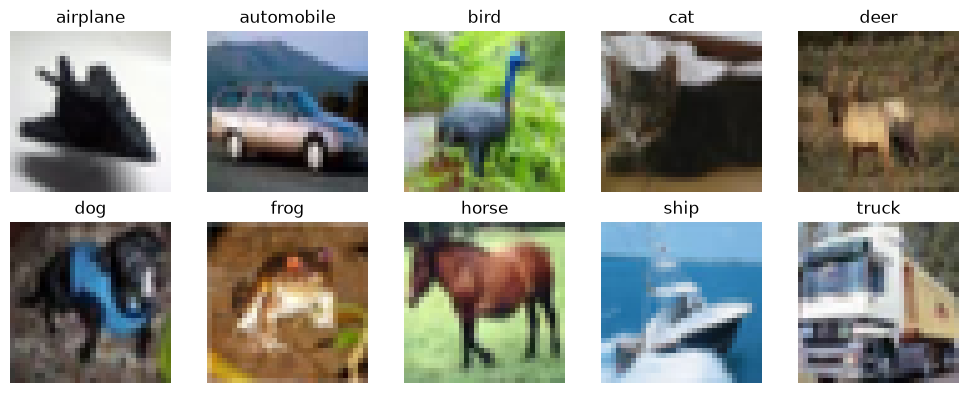

In [52]:
# Lista com os nomes das classes do conjunto de dados Fashion MNIST, na mesma ordem dos índices
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# Dicionário para armazenar um exemplo por classe
examples = {}

# Itera sobre o dataset até obter um exemplo de cada classe
for img, label in cifar_training_data:
    if label not in examples:
        examples[label] = img  # remove o canal extra (1, 28, 28) -> (28, 28)
    if len(examples) == 10:
        break

# Plota os exemplos
plt.figure(figsize=(10, 4))
for i in range(len(classes)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i].permute(1, 2, 0))
    plt.title(classes[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Construção do modelo

Implemente uma rede neural convolucional contendo:

- **camadas convolucionais**;
- **funções de ativação ReLU**;
- **camadas de pooling**;
- **normalização em lote** ([`BatchNorm2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html));
- **camadas totalmente conectadas** na parte final.

A rede deve conter pelo menos:

- 2 blocos convolucionais;
- cada bloco com convolução + batch normalization + ReLU;
- pelo menos 1 operação de pooling após blocos convolucionais;
- pelo menos 1 camada totalmente conectada antes da camada de saída;
- camada de saída compatível com as 10 classes do CIFAR-10.

Uma organização possível é:

- **Bloco 1:** `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d`
- **Bloco 2:** `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d`
- **Classificador:** `Flatten -> Linear -> ReLU -> Linear`

In [53]:
class ConvNetCIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=128 * 4 * 4, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 3. Treinamento do modelo

Treine inicialmente um modelo-base com a seguinte configuração:

- otimizador: `Adam`;
- função de perda: `CrossEntropyLoss`;
- número de épocas: `15`;
- taxa de aprendizagem inicial: `1e-3`;
- tamanho do lote inicial: `64`.

Durante o treinamento, registre:

- perda de treinamento por época;
- acurácia de treinamento por época;
- perda no teste por época;
- acurácia no teste por época.

Ao final salve o modelo e apresente:

- a acurácia final no conjunto de teste;
- um gráfico da perda ao longo das épocas;
- um gráfico da acurácia ao longo das épocas.

In [54]:
# Define a função de perda que será usada para treinar o modelo
# CrossEntropyLoss é adequada para tarefas de classificação multiclasse
loss_fn = nn.CrossEntropyLoss()

model_cnn_cifar = ConvNetCIFAR().to(device)

# Define o otimizador que irá ajustar os parâmetros da rede durante o treinamento
# Aqui, está sendo utilizado o otimizador SGD (Stochastic Gradient Descent) com taxa de aprendizado de 0.001
optimizer = torch.optim.Adam(model_cnn_cifar.parameters(), lr=1e-3)


In [55]:
epochs = 15  # Define o número total de épocas (iterações completas sobre o conjunto de dados de treinamento)
# Loop principal de treinamento, que executa uma vez para cada época
for t in range(epochs):
    print(f"Época {t+1}\n-------------------------------")  # Exibe o número da época atual (t + 1, pois t começa em 0)
    train(cifar_train_dataloader, model_cnn_cifar, loss_fn, optimizer)      # Chama a função de treinamento, passando os dados, modelo, função de perda e otimizador
    test(cifar_test_dataloader, model_cnn_cifar, loss_fn)                   # Chama a função de teste/validação após o treinamento da época atual
print("Fim!")  # Exibe mensagem final indicando que o treinamento terminou

Época 1
-------------------------------
loss: 2.325083  [   64/50000]
loss: 1.442441  [ 6464/50000]
loss: 1.084816  [12864/50000]
loss: 1.155321  [19264/50000]
loss: 1.438298  [25664/50000]
loss: 1.098102  [32064/50000]
loss: 0.920053  [38464/50000]
loss: 1.032217  [44864/50000]
Test Error: 
	Accuracy: 62.2%, Avg loss: 1.041805 

Época 2
-------------------------------
loss: 0.953488  [   64/50000]
loss: 1.014862  [ 6464/50000]
loss: 0.678935  [12864/50000]
loss: 1.015950  [19264/50000]
loss: 0.870118  [25664/50000]
loss: 1.018846  [32064/50000]
loss: 0.811999  [38464/50000]
loss: 1.106425  [44864/50000]
Test Error: 
	Accuracy: 70.5%, Avg loss: 0.873453 

Época 3
-------------------------------
loss: 0.696523  [   64/50000]
loss: 0.795471  [ 6464/50000]
loss: 0.670280  [12864/50000]
loss: 0.812572  [19264/50000]
loss: 0.933821  [25664/50000]
loss: 0.686590  [32064/50000]
loss: 0.766115  [38464/50000]
loss: 0.739304  [44864/50000]
Test Error: 
	Accuracy: 74.3%, Avg loss: 0.735320 

Époc